# Palantir Sample Dataset — scJDO Drift Field Analysis

Applies scJDO operator-level analysis to the bone marrow hematopoiesis dataset
from the Palantir sample notebook. The Palantir trajectory is used as-is;
scJDO adds:

- **Drift field** — learned directional dynamics from progenitor to each fate
- **Local Jacobian operators** — where is the system most sensitive to perturbation?
- **Archetype decomposition** — which regulatory programs activate and hand off?
- **Branch-separated analysis** — DC, Mono, and Ery lineages independently
- **Instability genes** — which genes drive dynamical sensitivity per lineage

**Dataset:** `marrow_sample_scseq_counts.h5ad` — 4,142 cells, 16,106 genes  
**Lineages:** Erythroid (Ery), Dendritic Cell (DC), Monocyte (Mono)

In [36]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scanpy as sc
import palantir
import scjdo as sjd
from scjdo.tl._drift import _pseudotime_velocity

OUTDIR = 'results/palantir_driftfield/'
os.makedirs(OUTDIR, exist_ok=True)

# ── Exact parameters from Palantir sample notebook ─────────────────────────
START_CELL      = 'Run5_164698952452459'
TERMINAL_STATES = pd.Series(
    ['DC',                   'Mono',                  'Ery'],
    index=['Run5_131097901611291', 'Run5_134936662236454', 'Run4_200562869397916']
)
N_WAYPOINTS     = 500

# ── scJDO config ─────────────────────────────────────────────────────────
N_ARCHETYPES    = 5
N_EPOCHS        = 5000   # increase to 50000 on GPU for publication quality
SEED            = 42

# ── Biology-informed velocity bias ─────────────────────────────────────────
# Uses Palantir fate probabilities to define terminal cell populations.
# bias_strength = 0   → pure pseudotime gradient (no prior knowledge)
# bias_strength = 1.5 → recommended: balanced constraint toward known fate
# bias_strength = 3–5 → strong constraint (noisy pseudotime / branch point)
BIAS_STRENGTH   = 1.5

print(f'scjdo v{sjd.__version__}')
print(f'palantir v{palantir.__version__}')

scjdo v0.3.0
palantir v1.4.4


## Step 1 — Reproduce Palantir preprocessing

Exact steps from `Palantir_sample_notebook.ipynb`.

In [37]:
# Load raw data (same file as Palantir notebook)
ad = sc.read(os.path.join('./', 'marrow_sample_scseq_counts.h5ad'))
print(f'Loaded: {ad.n_obs} cells x {ad.n_vars} genes')

# Store raw counts for reference
ad.layers['raw_counts'] = ad.X.copy()

# Normalize + log (Palantir uses pseudocount=0.1)
sc.pp.normalize_per_cell(ad)
palantir.preprocess.log_transform(ad)

# HVG + PCA
sc.pp.highly_variable_genes(ad, n_top_genes=1500, flavor='cell_ranger')
sc.pp.pca(ad)
print(f'PCA: varm["PCs"] shape = {ad.varm["PCs"].shape}')

# Diffusion maps (Palantir method — on PCA)
dm_res  = palantir.utils.run_diffusion_maps(ad, n_components=5)
ms_data = palantir.utils.determine_multiscale_space(ad)

# UMAP + neighbors
sc.pp.neighbors(ad)
sc.tl.umap(ad)

# MAGIC imputation (needed for gene trend visualization)
palantir.utils.run_magic_imputation(ad)

print('Preprocessing complete.')
print(f'obsm keys: {list(ad.obsm.keys())}')

Loaded: 4142 cells x 16106 genes
PCA: varm["PCs"] shape = (16106, 50)
Preprocessing complete.
obsm keys: ['X_pca', 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'X_umap']


## Step 2 — Run Palantir (identical to sample notebook)

In [38]:
# Run Palantir with known terminal states
pr_res = palantir.core.run_palantir(
    ad,
    START_CELL,
    num_waypoints   = N_WAYPOINTS,
    terminal_states = TERMINAL_STATES,
)
# Stored automatically:
#   ad.obs['palantir_pseudotime']       [0, 1]
#   ad.obs['palantir_entropy']
#   ad.obsm['palantir_fate_probabilities']  (DC, Mono, Ery)

print('Palantir results:')
print(f'  Pseudotime range: [{ad.obs["palantir_pseudotime"].min():.3f}, '
      f'{ad.obs["palantir_pseudotime"].max():.3f}]')
print(f'  Fate prob columns: {list(ad.obsm["palantir_fate_probabilities"].columns)}')

Sampling and flocking waypoints...
Time for determining waypoints: 8.406639099121094e-05 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.016946911811828613 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9999
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
Palantir results:
  Pseudotime range: [0.000, 1.000]
  Fate prob columns: ['Ery', 'DC', 'Mono']


Branch cell counts:
  Ery: 1551 cells (37%)
  DC: 1939 cells (47%)
  Mono: 2550 cells (62%)

Cell fate labels (used for velocity bias):
cell_fate
Mono          1987
Progenitor    1036
Ery            921
DC             198


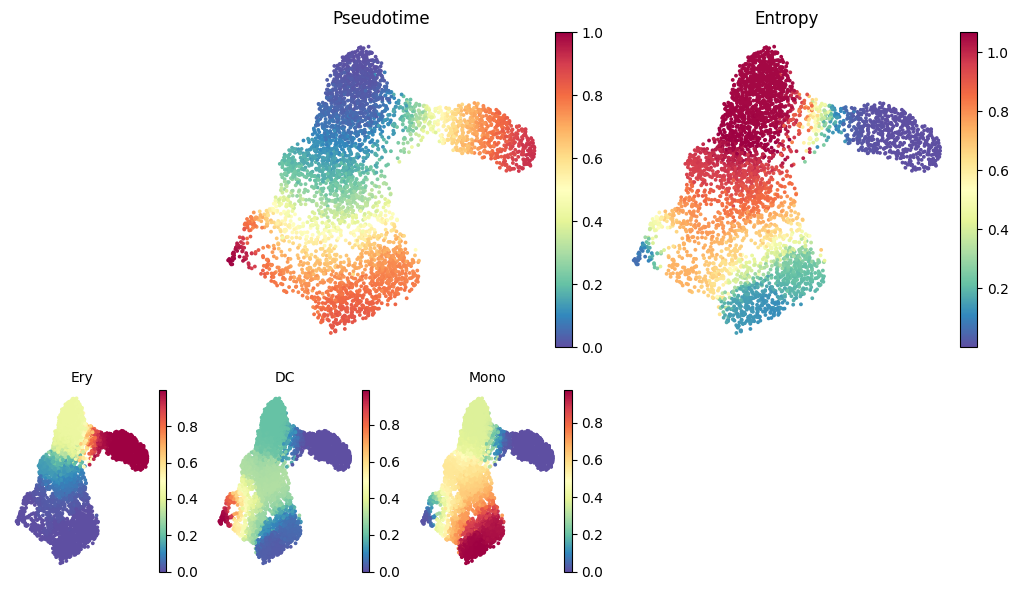

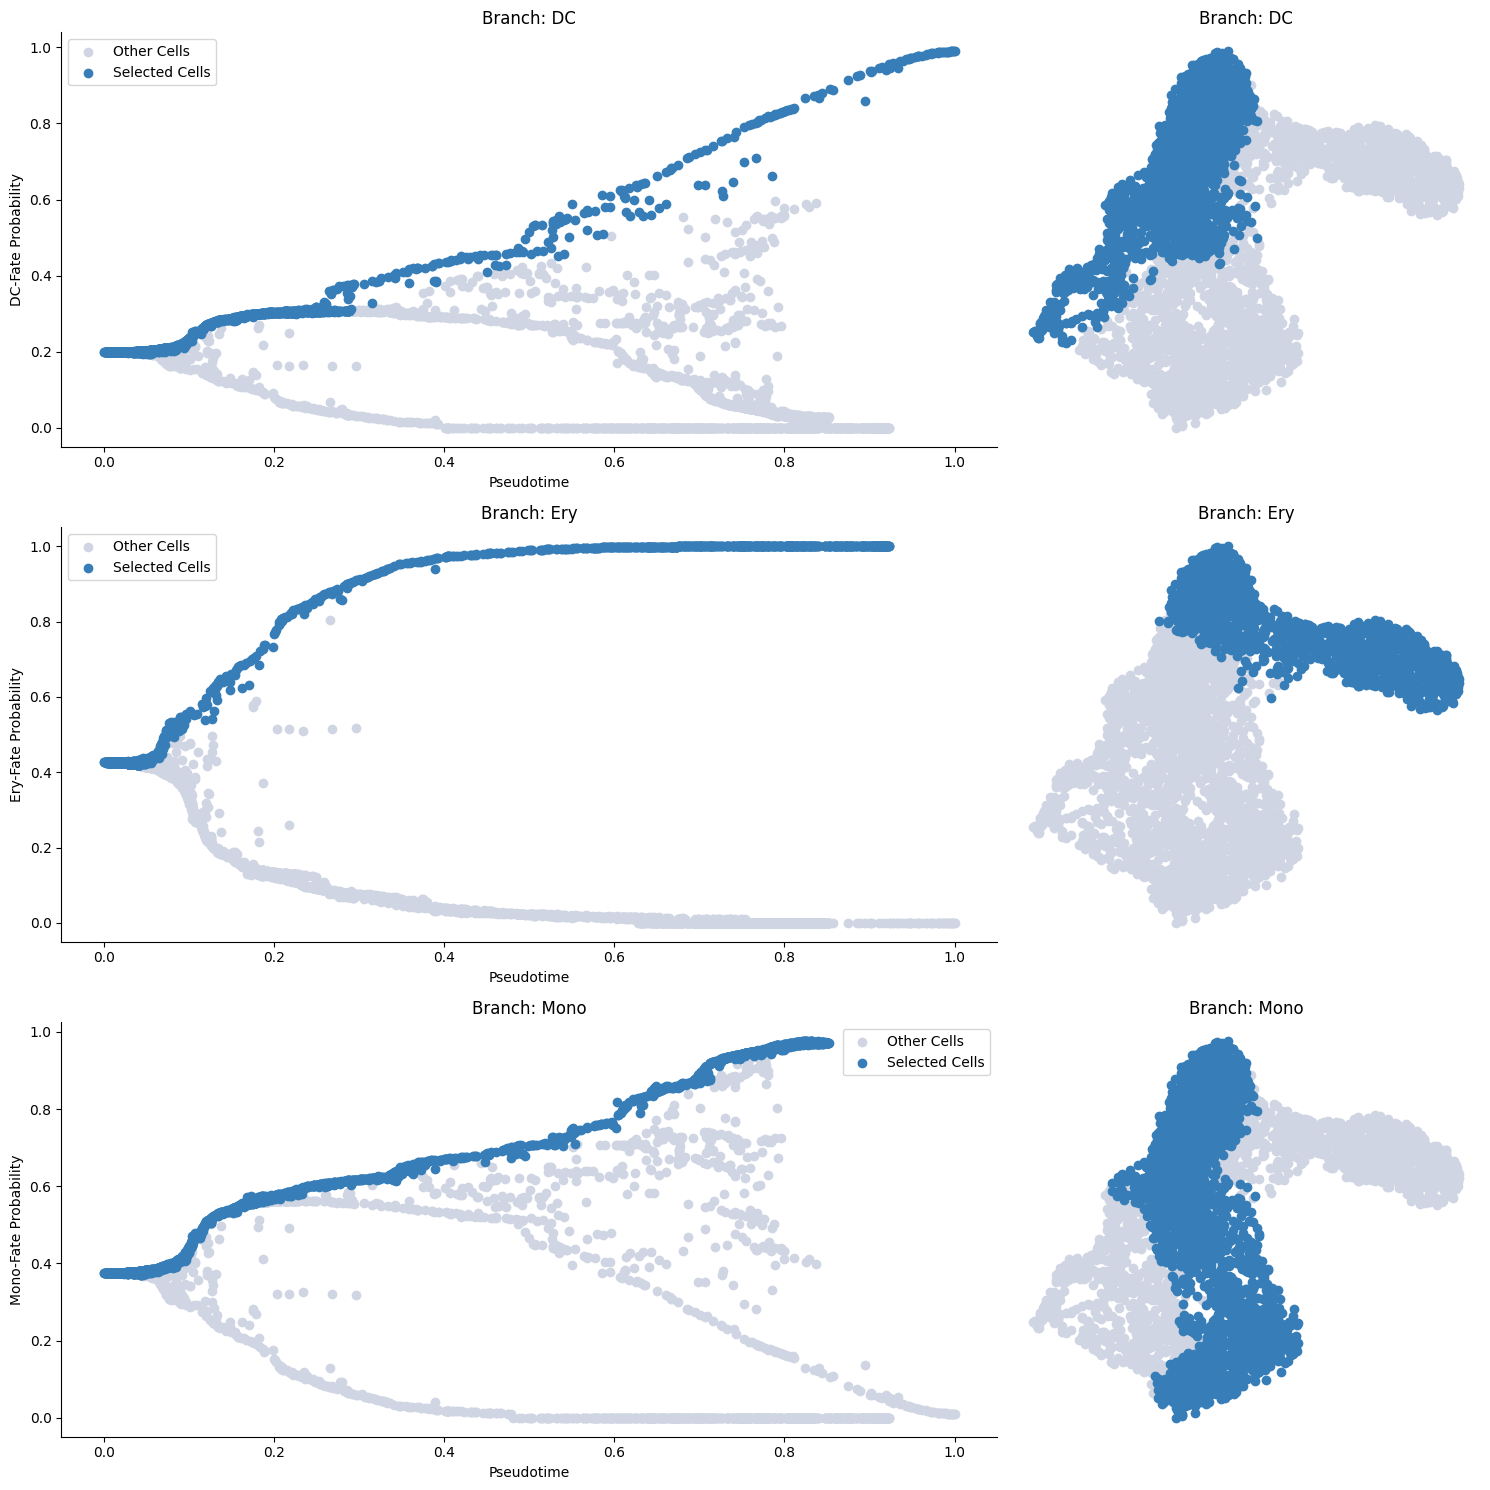

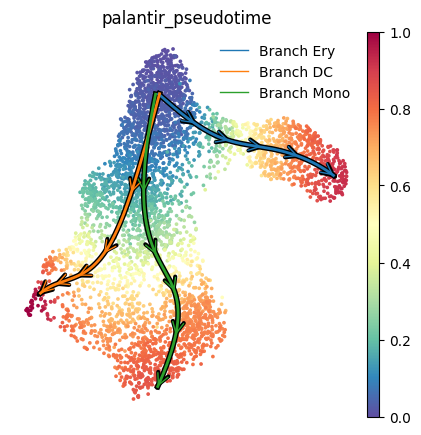

[2026-05-22 05:43:09,600] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (1,551) and rank = 1.0.
[2026-05-22 05:43:09,600] [INFO    ] Using covariance function Matern52(ls=1.0644395351409912).
[2026-05-22 05:43:09,601] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-05-22 05:43:09,611] [INFO    ] Sigma interpreted as element-wise standard deviation.


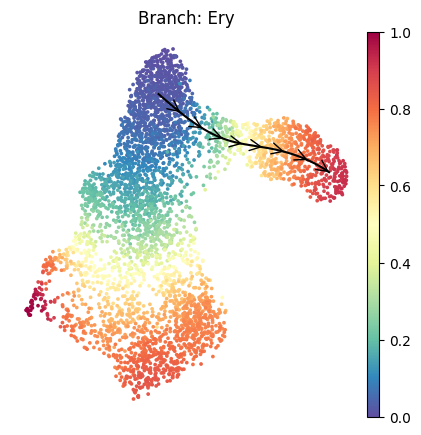

[2026-05-22 05:43:09,785] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (1,939) and rank = 1.0.
[2026-05-22 05:43:09,785] [INFO    ] Using covariance function Matern52(ls=1.0644395351409912).
[2026-05-22 05:43:09,785] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-05-22 05:43:09,795] [INFO    ] Sigma interpreted as element-wise standard deviation.


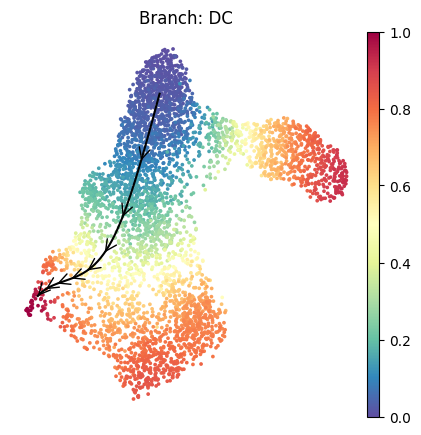

[2026-05-22 05:43:09,972] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (2,550) and rank = 1.0.
[2026-05-22 05:43:09,972] [INFO    ] Using covariance function Matern52(ls=1.0644395351409912).
[2026-05-22 05:43:09,972] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-05-22 05:43:09,984] [INFO    ] Sigma interpreted as element-wise standard deviation.


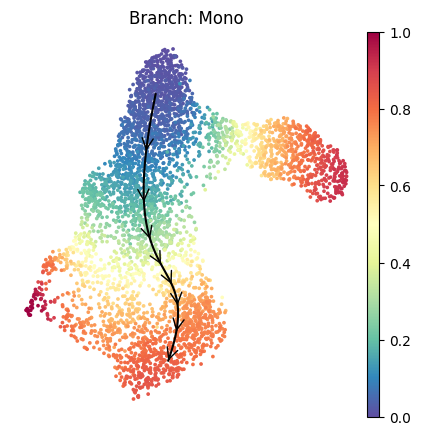

In [39]:
# ── select_branch_cells ─────────────────────────────────────────────────────
palantir.presults.select_branch_cells(ad, q=0.01, eps=0.01,
                                       masks_key='branch_masks', save_as_df=True)
masks_df = ad.obsm['branch_masks']
print('Branch cell counts:')
for col in masks_df.columns:
    n = masks_df[col].sum()
    print(f'  {col}: {n} cells ({100*n/len(ad):.0f}%)')

# ── Create cell_fate label for biology-informed bias ─────────────────────────
# Each cell is assigned to its dominant Palantir fate.
# High-entropy cells (top 25%) are labelled 'Progenitor' — these are the
# undifferentiated stem/progenitor cells that precede all lineages.
fate_probs = ad.obsm['palantir_fate_probabilities']
ad.obs['cell_fate'] = fate_probs.idxmax(axis=1).astype(str)

entropy_threshold = ad.obs['palantir_entropy'].quantile(0.75)
ad.obs.loc[ad.obs['palantir_entropy'] >= entropy_threshold, 'cell_fate'] = 'Progenitor'

print('\nCell fate labels (used for velocity bias):')
print(ad.obs['cell_fate'].value_counts().to_string())

# ── Palantir visualizations ──────────────────────────────────────────────────
palantir.plot.plot_palantir_results(ad, s=3)
plt.savefig(OUTDIR + 'palantir_results.pdf', dpi=150, bbox_inches='tight')
plt.show()

palantir.plot.plot_branch_selection(ad)
plt.savefig(OUTDIR + 'branch_selection.pdf', dpi=150, bbox_inches='tight')
plt.show()

palantir.plot.plot_trajectories(ad, pseudotime_interval=(0, 0.95))
plt.savefig(OUTDIR + 'trajectories.pdf', dpi=150, bbox_inches='tight')
plt.show()

for branch in ad.obsm['branch_masks'].columns:
    palantir.plot.plot_trajectory(ad, branch,
                                   cell_color='palantir_pseudotime', n_arrows=8)
    plt.savefig(OUTDIR + f'trajectory_{branch}.pdf', dpi=150, bbox_inches='tight')
    plt.show()

## Step 3 — scJDO branch-separated drift field analysis

Run scJDO independently on each Palantir branch (Ery, DC, Mono).
Each branch uses only its own cells — no cross-lineage Jacobian mixing.
The branch masks from Palantir include shared progenitors (correct biologically).

In [40]:
# Reload scjdo modules to pick up any code changes without restarting kernel
import importlib
import scjdo.tl._drift as _drift_mod
importlib.reload(_drift_mod)
import scjdo.tl as tl_mod
importlib.reload(tl_mod)
import scjdo
importlib.reload(scjdo)
import scjdo as sjd
print(f'scjdo reloaded — fit_drift_branches has bias params: '
      f'{"bias_strength" in str(__import__("inspect").signature(sjd.tl.fit_drift_branches))}')

scjdo reloaded — fit_drift_branches has bias params: True


In [43]:
# ── scJDO branch-separated with biology-informed velocity bias ─────────────
#
# The bias uses Palantir's own outputs as prior knowledge:
#   - 'Progenitor' label (high entropy)  → progenitor centroid
#   - 'DC', 'Mono', 'Ery' labels (dominant fate) → terminal centroids
#
# For each branch the velocity prior is:
#   V = pseudotime_gradient + BIAS_STRENGTH × pull_toward_terminal
# where pull_toward_terminal[i] = normalize(X_terminal - X[i]) × pseudotime[i]
# Cells projected onto the progenitor→terminal axis so lateral drift is suppressed.

branch_models = sjd.tl.fit_drift_branches(
    ad,
    branch_key         = 'branch_masks',
    branch_names       = list(ad.obsm['branch_masks'].columns),
    time_key           = 'palantir_pseudotime',
    # Biology-informed bias — derived from Palantir fate probabilities
    groupby            = 'cell_fate',      # column we just created above
    progenitor_cluster = 'Progenitor',     # high-entropy undifferentiated cells
    terminal_clusters  = {                 # dominant-fate cells per lineage
        'DC':   'DC',
        'Mono': 'Mono',
        'Ery':  'Ery',
    },
    bias_strength      = BIAS_STRENGTH,
    n_archetypes       = N_ARCHETYPES,
    n_epochs           = N_EPOCHS,
    vel_scale          = 2.0,
    seed               = SEED,
)

print('\nBranch results summary:')
for name in branch_models:
    key   = f'scjdo_{name}'
    r2    = ad.uns[key]['r2']
    n     = ad.uns[key]['n_cells']
    peak  = ad.uns[key]['t_centers'][np.argmax(ad.uns[key]['max_real_eig'])]
    print(f'  {name:6s}: {n:4d} cells | R2={r2:.3f} | '
          f'peak sensitivity at t={peak:.3f}')

[bias] Progenitor 'Progenitor': 1036 cells, centroid computed in X_pca

Branch: Ery  (1551 cells)
  [bias] Terminal 'Ery': 921 cells | bias_strength=1.5
  [bias] Alignment with prog→terminal axis: -0.128
[fit_drift] Using representation: X_pca (latent=pca)
Computing pseudotime-gradient velocity prior...
DriftField: 894,692 parameters | device=cpu | epochs=5000


Training drift field:   0%|          | 0/5000 [00:00<?, ?it/s]

Training complete. Final loss: 97.4762
Computing Jacobian tensor...


Jacobians:   0%|          | 0/100 [00:00<?, ?it/s]

Running archetype decomposition (semi-NMF)...
Done. R²=0.995 | Archetypes stored in adata.uns['scjdo_branch']
  Done. R²=0.995  stored in adata.uns['scjdo_Ery']

Branch: DC  (1939 cells)
  [bias] Terminal 'DC': 198 cells | bias_strength=1.5
  [bias] Alignment with prog→terminal axis: 0.261
[fit_drift] Using representation: X_pca (latent=pca)
Computing pseudotime-gradient velocity prior...
DriftField: 894,692 parameters | device=cpu | epochs=5000


...

Running archetype decomposition (semi-NMF)...
Done. R²=0.982 | Archetypes stored in adata.uns['scjdo_branch']
  Done. R²=0.982  stored in adata.uns['scjdo_DC']

Branch: Mono  (2550 cells)
  [bias] Terminal 'Mono': 1987 cells | bias_strength=1.5
  [bias] Alignment with prog→terminal axis: 0.000
[fit_drift] Using representation: X_pca (latent=pca)
Computing pseudotime-gradient velocity prior...
DriftField: 894,692 parameters | device=cpu | epochs=5000


Training drift field:   0%|          | 0/5000 [00:00<?, ?it/s]

Training complete. Final loss: 100.0922
Computing Jacobian tensor...


Jacobians:   0%|          | 0/100 [00:00<?, ?it/s]

Running archetype decomposition (semi-NMF)...
Done. R²=0.990 | Archetypes stored in adata.uns['scjdo_branch']
  Done. R²=0.990  stored in adata.uns['scjdo_Mono']

Branch results stored: ['scjdo_Ery', 'scjdo_DC', 'scjdo_Mono']

Branch results summary:
  Ery   : 1551 cells | R2=0.995 | peak sensitivity at t=0.562
  DC    : 1939 cells | R2=0.982 | peak sensitivity at t=0.976
  Mono  : 2550 cells | R2=0.990 | peak sensitivity at t=0.476


## Step 4 — Per-branch figures

For each lineage: drift field, local sensitivity, archetype profiles, coordination.

In [54]:
ad_b

AnnData object with n_obs × n_vars = 2550 × 16106
    obs: 'n_counts', 'palantir_pseudotime', 'palantir_entropy', 'cell_fate'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'pca', 'DM_EigenValues', 'neighbors', 'umap', 'palantir_waypoints', 'palantir_fates_colors', 'scjdo_Ery', 'scjdo_DC', 'scjdo_Mono'
    obsm: 'X_pca', 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'X_umap', 'palantir_fate_probabilities', 'branch_masks', 'X_velocity_pseudo', 'X_drift'
    varm: 'PCs'
    layers: 'raw_counts', 'MAGIC_imputed_data'
    obsp: 'DM_Kernel', 'DM_Similarity', 'distances', 'connectivities'


=== Ery lineage (1551 cells) ===


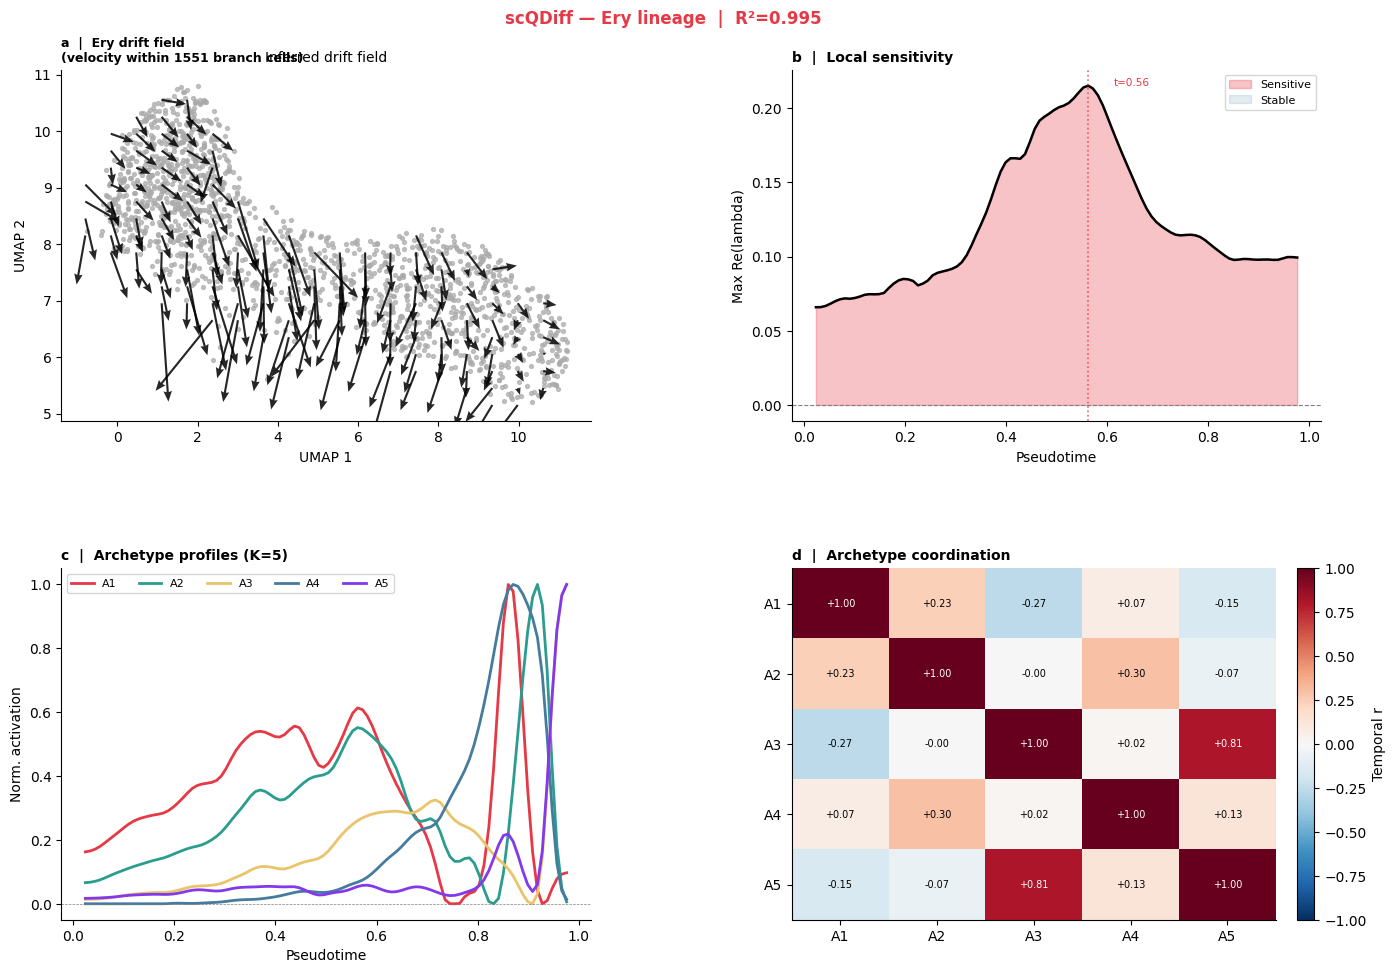

Saved: results/palantir_driftfield/figure_Ery.pdf

=== DC lineage (1939 cells) ===


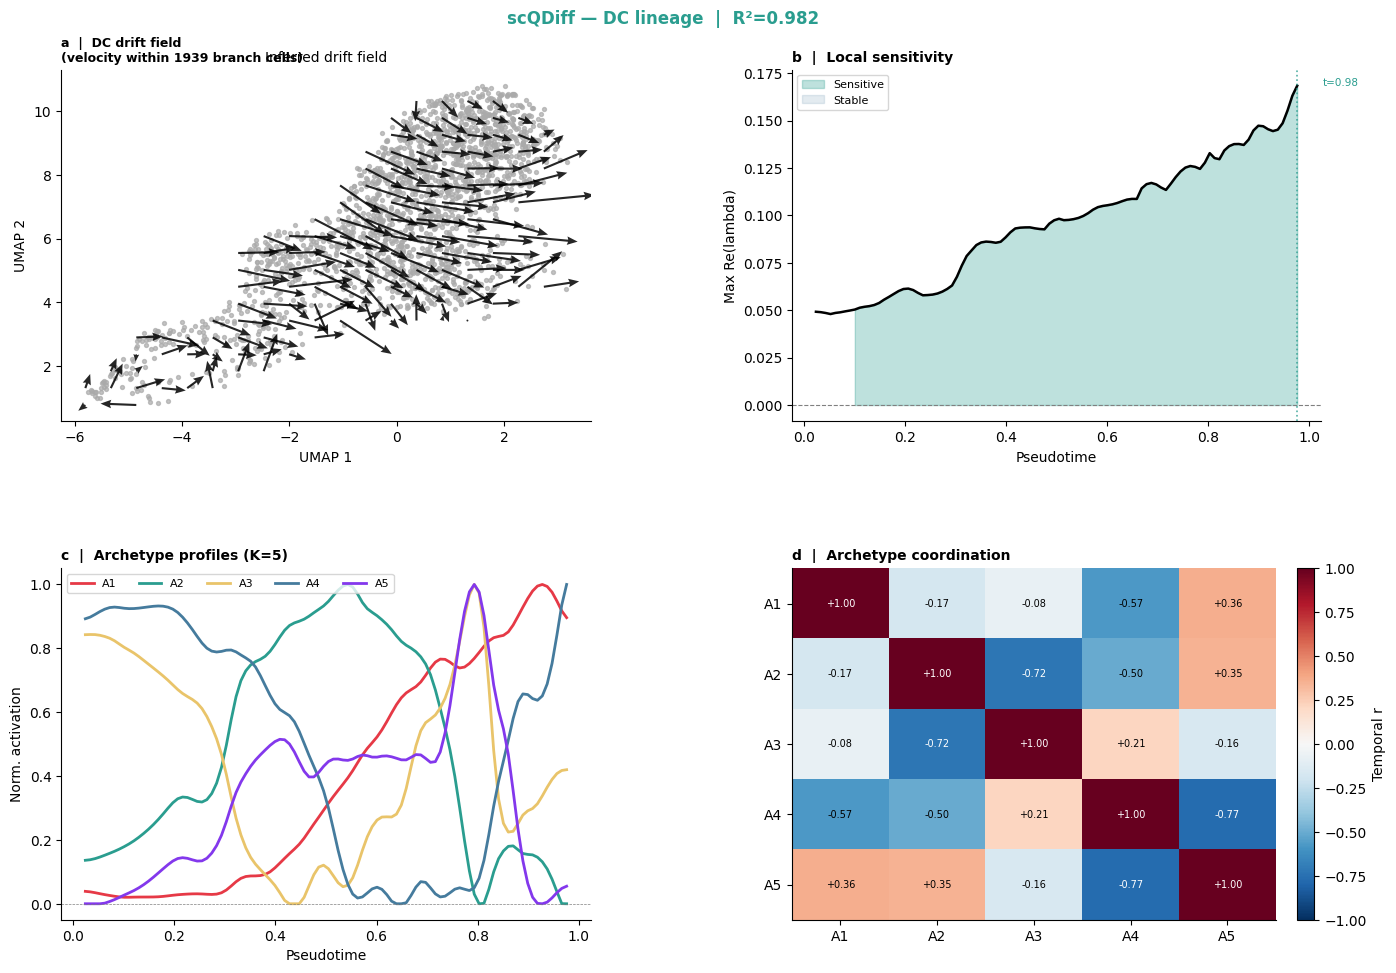

Saved: results/palantir_driftfield/figure_DC.pdf

=== Mono lineage (2550 cells) ===


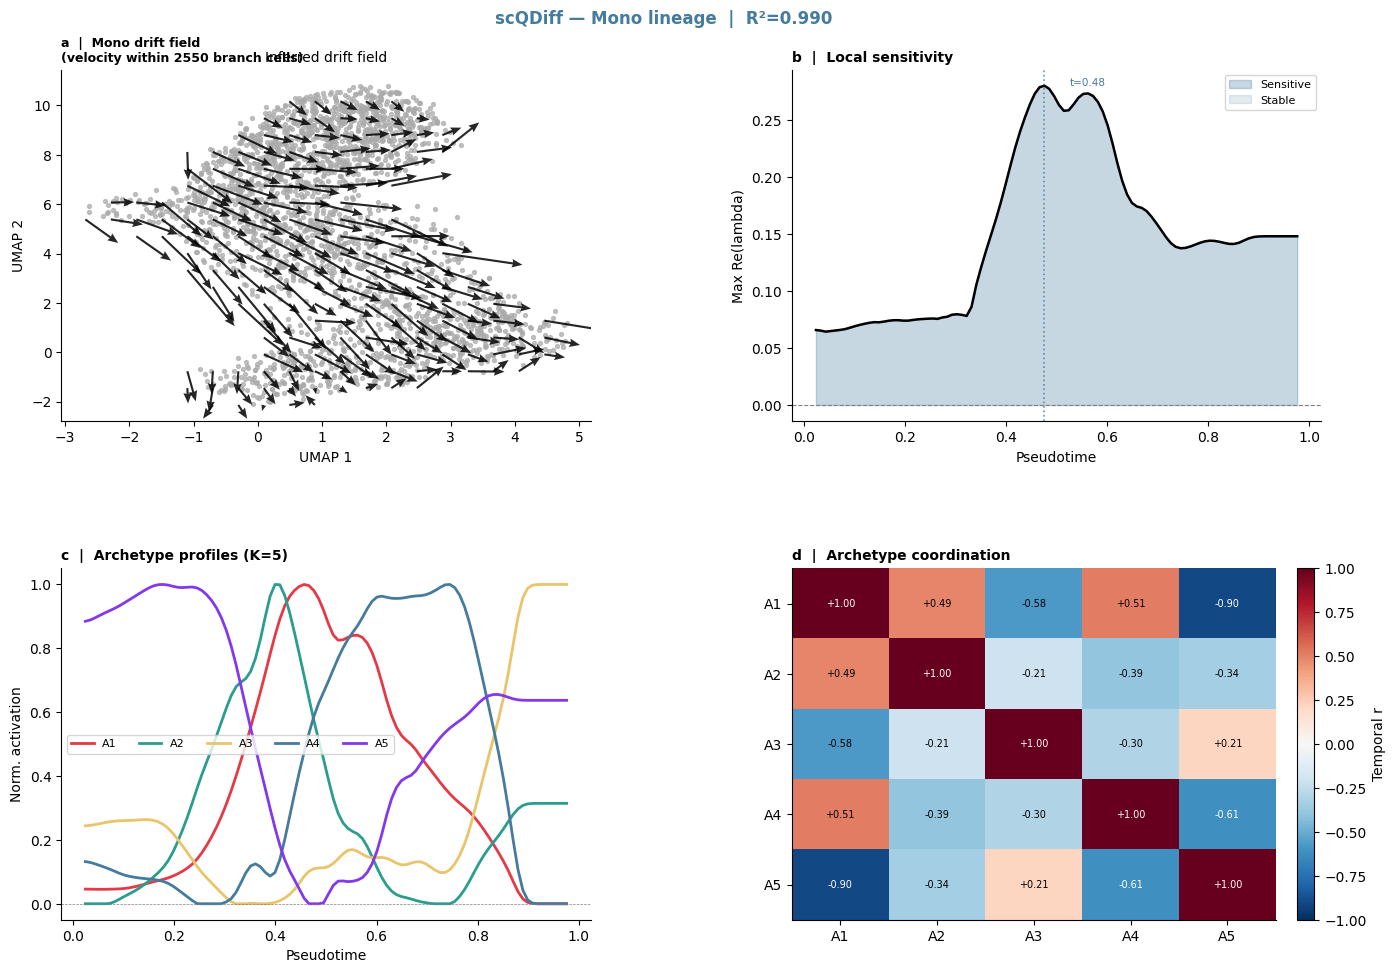

Saved: results/palantir_driftfield/figure_Mono.pdf


In [55]:
BRANCH_COLORS = {'Ery': '#E63946', 'DC': '#2A9D8F', 'Mono': '#457B9D'}
ARCH_COLORS   = ['#E63946','#2A9D8F','#E9C46A','#457B9D','#8338EC']

for branch in branch_models:
    key      = f'scjdo_{branch}'
    cell_idx = np.array(ad.uns[key]['branch_cells'])
    print(f'\n=== {branch} lineage ({len(cell_idx)} cells) ===')

    # Subset to branch cells
    ad_b = ad[cell_idx].copy()
    ad_b.uns[key] = ad.uns[key]

    # Compute branch-specific velocity (arrows point correctly along THIS lineage)
    X_branch  = ad_b.obsm['X_pca'].astype('float32')
    pt_branch = ad_b.obs['palantir_pseudotime'].values.astype('float32')
    V_branch  = _pseudotime_velocity(X_branch, pt_branch, k=15)
    ad_b.obsm['X_velocity_pseudo'] = V_branch
    if 'X_drift' in ad.uns[key]:
        ad_b.obsm['X_drift'] = ad.uns[key]['X_drift']

    res     = ad.uns[key]
    t_np    = res['t_centers']
    max_eig = res['max_real_eig']
    act     = res['act_norm']
    corr    = res['corr_mat']
    K       = act.shape[1]
    branch_col = BRANCH_COLORS.get(branch, '#555')

    # ── 4-panel manuscript figure ─────────────────────────────────────────
    fig = plt.figure(figsize=(14, 10))
    gs  = gridspec.GridSpec(2, 2, hspace=0.42, wspace=0.38,
                            left=0.07, right=0.97, top=0.92, bottom=0.07)
    ax_a = fig.add_subplot(gs[0, 0])
    ax_b = fig.add_subplot(gs[0, 1])
    ax_c = fig.add_subplot(gs[1, 0])
    ax_d = fig.add_subplot(gs[1, 1])

    # Panel a — drift field on UMAP (branch-specific velocity)
    sjd.pl.drift_field(
        ad_b, key=key,
        basis        = 'X_umap',
        color        = 'Pseudotime',
        velocity_key = 'X_velocity_pseudo',
        stream       = False,
        n_grid       = 18,
        min_cells    = 2,
        ax           = ax_a,
    )
    ax_a.set_title(f'a  |  {branch} drift field\n'
                   f'(velocity within {len(cell_idx)} branch cells)',
                   fontweight='bold', loc='left', fontsize=9)

    # Panel b — local sensitivity
    sens = max_eig >= 0.05
    ax_b.plot(t_np, max_eig, color='black', lw=1.8)
    ax_b.fill_between(t_np, max_eig, 0, where=sens,
                      alpha=0.30, color=branch_col, label='Sensitive')
    ax_b.fill_between(t_np, max_eig, 0, where=max_eig<=-0.05,
                      alpha=0.15, color='#457B9D', label='Stable')
    ax_b.axhline(0, color='gray', lw=0.8, ls='--')
    peak_t = t_np[np.argmax(max_eig)]
    ax_b.axvline(peak_t, color=branch_col, lw=1.2, ls=':', alpha=0.8)
    ax_b.annotate(f't={peak_t:.2f}', xy=(peak_t, max_eig.max()),
                  xytext=(peak_t+0.05, max_eig.max()),
                  fontsize=7.5, color=branch_col)
    ax_b.set_xlabel('Pseudotime'); ax_b.set_ylabel('Max Re(lambda)')
    ax_b.set_title('b  |  Local sensitivity',
                   fontweight='bold', loc='left', fontsize=10)
    ax_b.legend(fontsize=8)

    # Panel c — archetype activation profiles
    for k in range(K):
        ax_c.plot(t_np, act[:, k], color=ARCH_COLORS[k], lw=2, label=f'A{k+1}')
    ax_c.axhline(0, color='gray', lw=0.5, ls='--')
    ax_c.set_xlabel('Pseudotime'); ax_c.set_ylabel('Norm. activation')
    ax_c.set_title(f'c  |  Archetype profiles (K={K})',
                   fontweight='bold', loc='left', fontsize=10)
    ax_c.legend(ncol=K, fontsize=8)

    # Panel d — coordination heatmap
    im = ax_d.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
    ax_d.set_xticks(range(K)); ax_d.set_xticklabels([f'A{k+1}' for k in range(K)])
    ax_d.set_yticks(range(K)); ax_d.set_yticklabels([f'A{k+1}' for k in range(K)])
    for i in range(K):
        for j in range(K):
            ax_d.text(j, i, f'{corr[i,j]:+.2f}', ha='center', va='center',
                      fontsize=7, color='white' if abs(corr[i,j])>0.6 else 'black')
    plt.colorbar(im, ax=ax_d, label='Temporal r', fraction=0.046, pad=0.04)
    ax_d.set_title('d  |  Archetype coordination',
                   fontweight='bold', loc='left', fontsize=10)

    fig.suptitle(f'scJDO — {branch} lineage  |  R²={res["r2"]:.3f}',
                 fontsize=12, fontweight='bold', color=branch_col)
    save_path = OUTDIR + f'figure_{branch}.pdf'
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'Saved: {save_path}')

## Step 5 — Instability genes per lineage

Which genes drive dynamical sensitivity in each lineage?


Ery lineage — instability genes


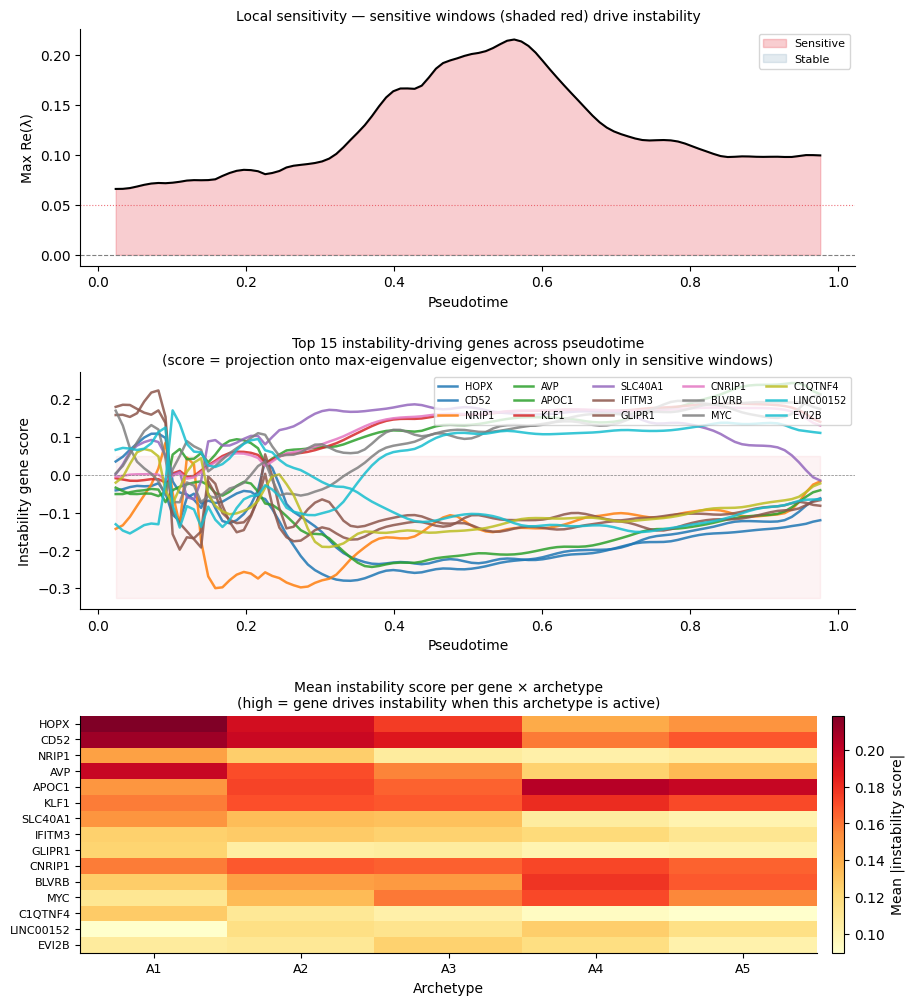

 rank      gene  mean_instability_score  peak_pseudotime primary_archetype
    1      HOPX                  0.1646            0.341                A1
    2      CD52                  0.1600            0.438                A1
    3     NRIP1                  0.1479            0.159                A1
    4       AVP                  0.1393            0.370                A1
    5     APOC1                  0.1286            0.938                A2
    6      KLF1                  0.1230            0.851                A4
    7   SLC40A1                  0.1229            0.428                A1
    8    IFITM3                  0.1227            0.082                A1
    9    GLIPR1                  0.1212            0.111                A1
   10    CNRIP1                  0.1210            0.841                A4
   11     BLVRB                  0.1159            0.899                A4
   12       MYC                  0.1077            0.976                A3
   13   C1QTNF4          

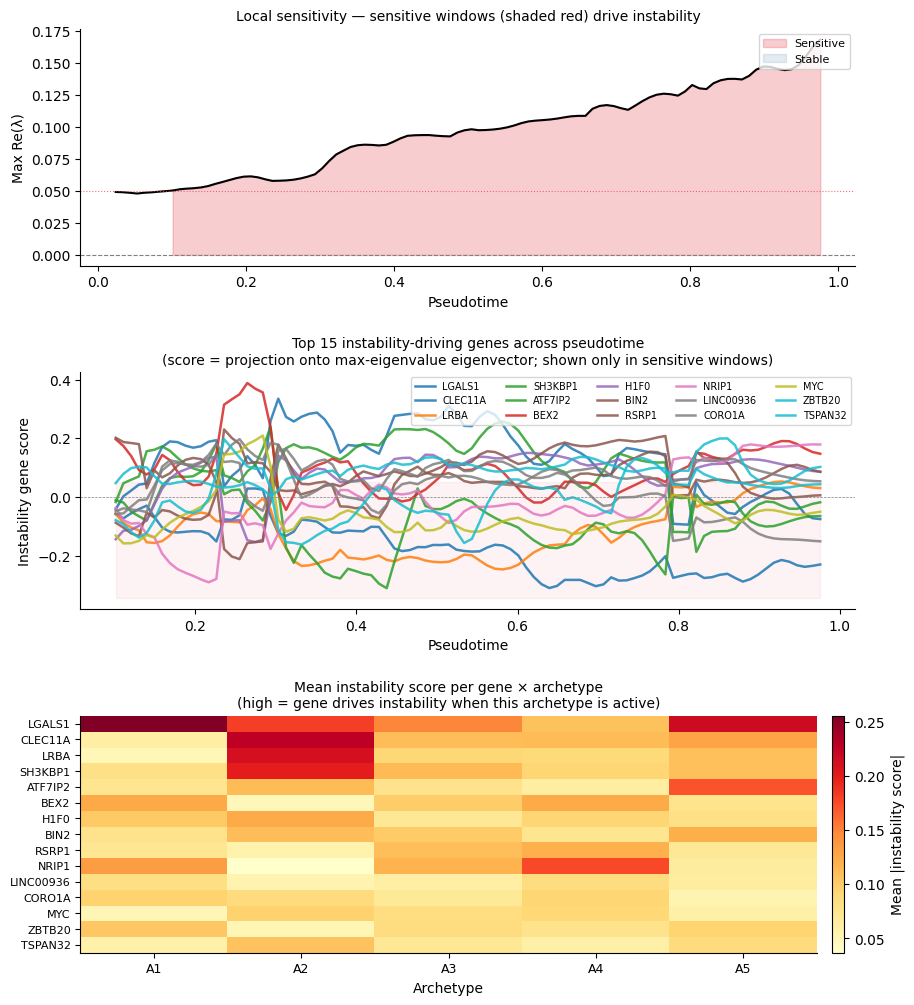

 rank      gene  mean_instability_score  peak_pseudotime primary_archetype
    1    LGALS1                  0.1688            0.639                A2
    2   CLEC11A                  0.1423            0.303                A4
    3      LRBA                  0.1209            0.582                A2
    4   SH3KBP1                  0.1209            0.582                A2
    5   ATF7IP2                  0.1063            0.438                A2
    6      BEX2                  0.1032            0.264                A4
    7      H1F0                  0.1022            0.274                A4
    8      BIN2                  0.0972            0.236                A4
    9     RSRP1                  0.0929            0.255                A4
   10     NRIP1                  0.0873            0.216                A4
   11 LINC00936                  0.0847            0.255                A4
   12    CORO1A                  0.0837            0.312                A4
   13       MYC          

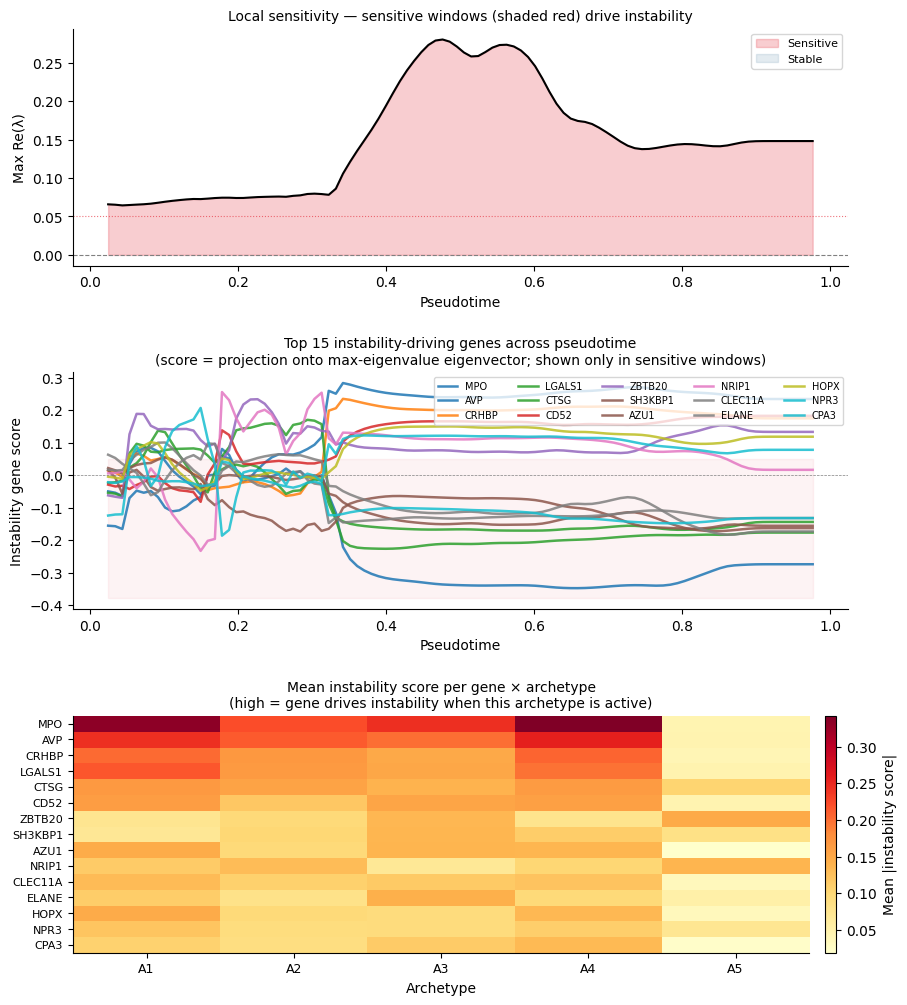

 rank    gene  mean_instability_score  peak_pseudotime primary_archetype
    1     MPO                  0.2305            0.659                A4
    2     AVP                  0.1886            0.341                A2
    3   CRHBP                  0.1481            0.341                A2
    4  LGALS1                  0.1480            0.399                A2
    5    CTSG                  0.1426            0.591                A4
    6    CD52                  0.1244            0.938                A3
    7  ZBTB20                  0.1098            0.226                A5
    8 SH3KBP1                  0.1049            0.284                A5
    9    AZU1                  0.1033            0.841                A5
   10   NRIP1                  0.1023            0.178                A5
   11 CLEC11A                  0.0991            0.322                A5
   12   ELANE                  0.0963            0.861                A3
   13    HOPX                  0.0950            0.

In [45]:
gene_tables = {}

for branch in branch_models:
    key      = f'scjdo_{branch}'
    cell_idx = np.array(ad.uns[key]['branch_cells'])
    ad_b     = ad[cell_idx].copy()
    ad_b.uns[key]    = ad.uns[key]
    if 'PCs' in ad.varm:
        ad_b.varm['PCs'] = ad.varm['PCs']

    print(f'\n{"="*55}')
    print(f'{branch} lineage — instability genes')
    print(f'{"="*55}')
    table = sjd.pl.instability_genes(
        ad_b,
        key     = key,
        n_genes = 15,
        save    = OUTDIR + f'instability_genes_{branch}.pdf',
    )
    gene_tables[branch] = table
    table.to_csv(OUTDIR + f'instability_genes_{branch}.csv', index=False)

## Step 6 — Regulatory network per lineage

Which TFs drive instability in DC vs Mono vs Ery programs?

In [46]:
# Normalize gene names (IMPORTANT)
ad_b.var_names = ad_b.var_names.str.upper()

df_reg = sjd.tl.infer_regulators(
    ad_b,
    key=key,
    organism='mouse',     # critical for Paul15
    n_top=10,
    min_targets=2,
    key_added=reg_key,
    verbose=True,
)

print("Shape:", df_reg.shape)
print("Columns:", df_reg.columns)

if df_reg.shape[0] > 0:
    sjd.pl.regulator_network(
        ad_b,
        key=reg_key,
        scjdo_key=key,
        n_tfs=10,
        n_targets=10,
        save=OUTDIR + f'regulator_network_{branch}.pdf',
    )
else:
    print(f"⚠️ No regulators found for {branch}")

[network] TRRUST v2 loaded — 7,057 edges
[forward] Scoring regulators against 16106 genes...
  Top 5: 
  De novo edges: 1473
Shape: (0, 10)
Columns: Index(['regulator', 'weighted_score', 'mean_instability', 'enrichment_score',
       'branch_specificity', 'peak_archetype', 'db_confidence', 'n_targets',
       'enrichment_pval', 'top_targets'],
      dtype='object')
⚠️ No regulators found for Mono


## Step 7 — Cross-lineage comparison

Which instability genes and regulators are lineage-specific vs shared across DC, Mono, Ery?

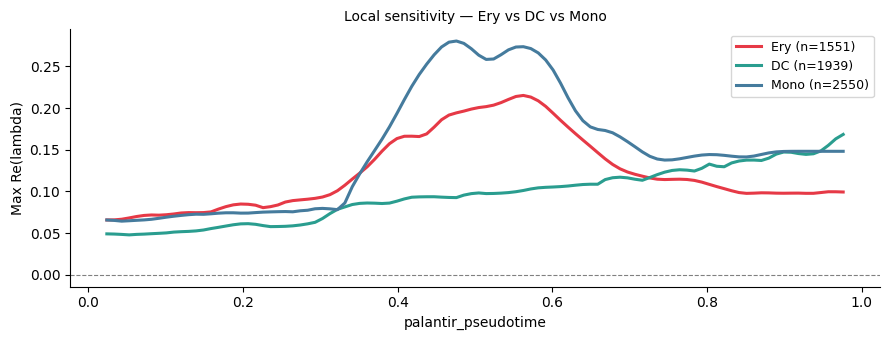


Instability gene overlap:
  Ery-specific (10): APOC1, BLVRB, C1QTNF4, CNRIP1, EVI2B, GLIPR1, IFITM3, KLF1
  DC-specific (9): ATF7IP2, BEX2, BIN2, CORO1A, H1F0, LINC00936, LRBA, RSRP1
  Mono-specific (7): AZU1, CPA3, CRHBP, CTSG, ELANE, MPO, NPR3
  Shared:          NRIP1

Regulator overlap:


In [47]:
branches = list(branch_models.keys())

# ── Sensitivity profiles side-by-side ────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 3.5))
for branch in branches:
    key = f'scjdo_{branch}'
    t   = ad.uns[key]['t_centers']
    eig = ad.uns[key]['max_real_eig']
    n   = ad.uns[key]['n_cells']
    ax.plot(t, eig, color=BRANCH_COLORS.get(branch,'#555'),
            lw=2.2, label=f'{branch} (n={n})')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('palantir_pseudotime'); ax.set_ylabel('Max Re(lambda)')
ax.set_title('Local sensitivity — Ery vs DC vs Mono', fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTDIR + 'sensitivity_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()

# ── Instability gene overlap ──────────────────────────────────────────────
print('\nInstability gene overlap:')
gene_sets = {b: set(gene_tables[b]['gene']) for b in branches if b in gene_tables}
for b in gene_sets:
    others = [gene_sets[o] for o in gene_sets if o != b]
    unique = gene_sets[b] - set.union(*others) if others else gene_sets[b]
    uniq_str = ', '.join(sorted(unique)[:8])
    print(f'  {b}-specific ({len(unique)}): {uniq_str}')
if len(gene_sets) > 1:
    shared_str = ', '.join(sorted(set.intersection(*gene_sets.values()))[:8])
    print(f'  Shared:          {shared_str}')

# ── Regulator overlap ─────────────────────────────────────────────────────
print('\nRegulator overlap:')
reg_sets = {b: set(reg_tables[b]['regulator']) for b in branches if b in reg_tables}
for b in reg_sets:
    others = [reg_sets[o] for o in reg_sets if o != b]
    unique = reg_sets[b] - set.union(*others) if others else reg_sets[b]
    #print(f'  {b}-specific ({len(unique)}): {', '.join(sorted(unique)[:6])}')
if len(reg_sets) > 1:
    shared = set.intersection(*reg_sets.values())
    #print(f'  Shared ({len(shared)}): {', '.join(sorted(shared)[:6])}')

## Step 8 — Save annotated data

In [56]:
ad

AnnData object with n_obs × n_vars = 4142 × 16106
    obs: 'n_counts', 'palantir_pseudotime', 'palantir_entropy', 'cell_fate'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'pca', 'DM_EigenValues', 'neighbors', 'umap', 'palantir_waypoints', 'palantir_fates_colors', 'scjdo_Ery', 'scjdo_DC', 'scjdo_Mono'
    obsm: 'X_pca', 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'X_umap', 'palantir_fate_probabilities', 'branch_masks'
    varm: 'PCs'
    layers: 'raw_counts', 'MAGIC_imputed_data'
    obsp: 'DM_Kernel', 'DM_Similarity', 'distances', 'connectivities'

In [48]:
import json

# Summary table
rows = []
for branch in branch_models:
    key = f'scjdo_{branch}'
    res = ad.uns[key]
    rows.append({
        'branch':               branch,
        'n_cells':              res['n_cells'],
        'r2':                   round(float(res['r2']), 3),
        'peak_sensitivity_pt':  round(float(
            res['t_centers'][np.argmax(res['max_real_eig'])]), 3),
        'max_sensitivity':      round(float(res['max_real_eig'].max()), 4),
        'top_instab_gene':      (res['top_instability_genes'][0]
                                 if res.get('top_instability_genes') else ''),
        'top_regulator':        (reg_tables[branch]['regulator'].iloc[0]
                                 if branch in reg_tables else ''),
    })

summary = pd.DataFrame(rows)
summary.to_csv(OUTDIR + 'branch_summary.csv', index=False)
print('Branch summary:')
print(summary.to_string(index=False))

# Save processed AnnData with all scJDO results
ad.write_h5ad(OUTDIR + 'marrow_scjdo.h5ad')
print(f'\nSaved: {OUTDIR}marrow_scjdo.h5ad')
print(f'\nAll outputs in: {OUTDIR}')
import pathlib
for f in sorted(pathlib.Path(OUTDIR).iterdir()):
    print(f'  {f.name}')

IndexError: single positional indexer is out-of-bounds